Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='str')


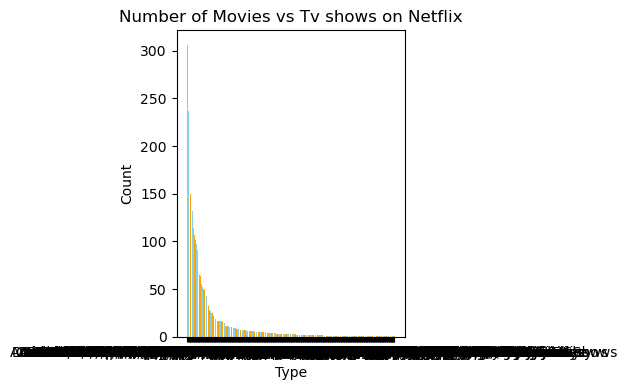

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('Netflix_Dataset.csv')

# print(df.columns)

# clean data

df = df.dropna(subset=['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'])

type_counts = df['Type'].value_counts()
plt.figure(figsize=(6,4))

plt.bar(type_counts.index, type_counts.values, color = ['skyblue', 'orange'])
plt.title('Number of Movies vs Tv shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')

plt.tight_layout()

plt.savefig('movies_vs_tvshows.png')
plt.show()

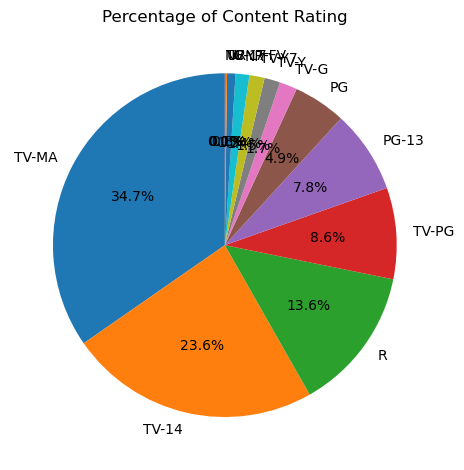

In [5]:
rating_counts = df['Rating'].value_counts()
plt.Figure(figsize=(10,15))
plt.pie(rating_counts, labels=rating_counts.index, autopct= '%1.1f%%',startangle=90)
plt.title('Percentage of Content Rating')
plt.tight_layout()
plt.savefig('movie_rating.png')

plt.show()


In [14]:
print(df['Type'].unique())

<StringArray>
[                            'Dramas, International Movies',
                      'Horror Movies, International Movies',
 'Action & Adventure, Independent Movies, Sci-Fi & Fantasy',
                                                   'Dramas',
          'International TV Shows, TV Dramas, TV Mysteries',
           'Horror Movies, International Movies, Thrillers',
                                        'Dramas, Thrillers',
       'Documentaries, International Movies, Sports Movies',
          'Independent Movies, Sci-Fi & Fantasy, Thrillers',
                  'Dramas, International Movies, Thrillers',
 ...
                      'Comedies, Cult Movies, LGBTQ Movies',
         'British TV Shows, Classic & Cult TV, TV Comedies',
                'Comedies, Horror Movies, Sci-Fi & Fantasy',
              'Action & Adventure, Comedies, Horror Movies',
         'Action & Adventure, Documentaries, Sports Movies',
   'Anime Features, International Movies, Sci-Fi & Fantasy',
     

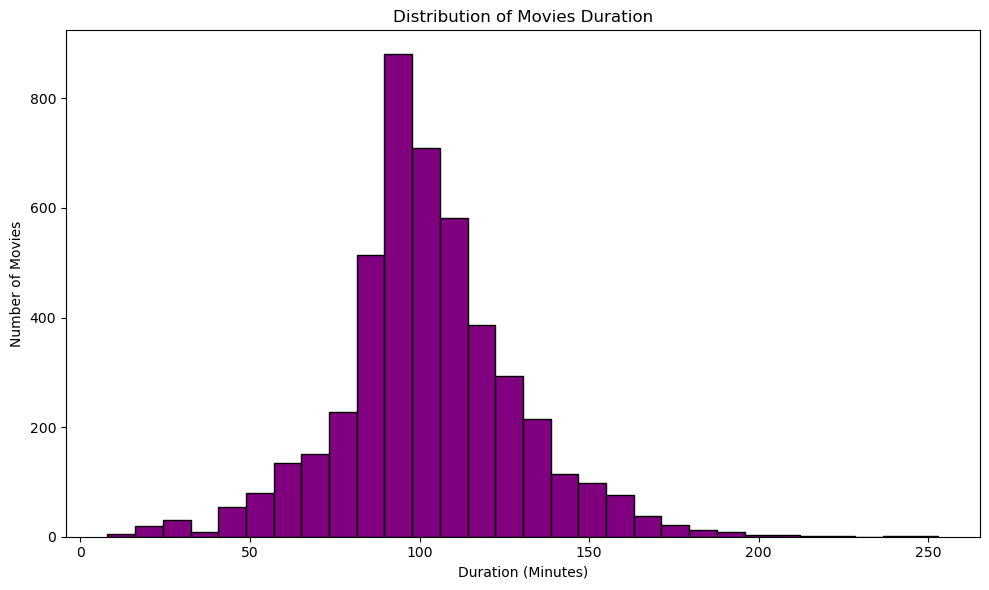

In [17]:

# Filter only movies
movie_df = df[df['Category'] == 'Movie'].copy()

# Remove rows with missing duration
movie_df = movie_df.dropna(subset=['Duration'])

# Keep only rows containing 'min'
movie_df = movie_df[movie_df['Duration'].str.contains('min')]

# Convert duration to integer
movie_df['duration_int'] = movie_df['Duration'].str.replace(' min', '', regex=False).astype(int)


# Plot histogram
plt.figure(figsize=(10,6))

plt.hist(movie_df['duration_int'],
         bins=30,
         color='purple',
         edgecolor='black')

plt.title('Distribution of Movies Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.savefig('Movies_duration_histogram.png')
plt.tight_layout()
plt.show()

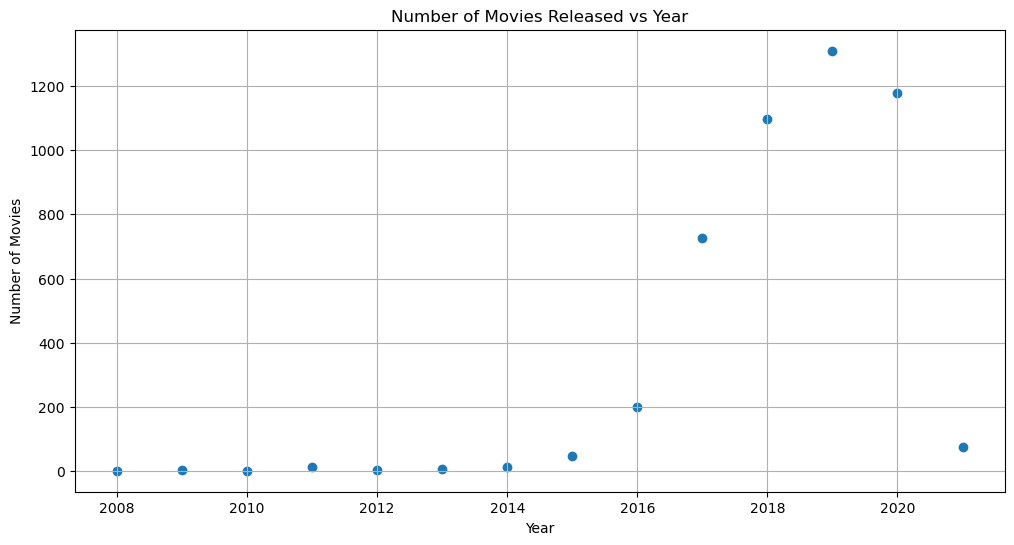

In [18]:

# Filter only movies
movie_df = df[df['Category'] == 'Movie'].copy()

# Convert Release_Date to datetime
movie_df['Release_Date'] = pd.to_datetime(movie_df['Release_Date'])

# Extract year
movie_df['Year'] = movie_df['Release_Date'].dt.year

# Count movies released each year
movies_per_year = movie_df['Year'].value_counts().sort_index()

# Scatter plot
plt.figure(figsize=(12,6))

plt.scatter(movies_per_year.index,
            movies_per_year.values)

plt.title('Number of Movies Released vs Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')

plt.grid(True)

plt.savefig('Movies released in a year.png')

plt.show()

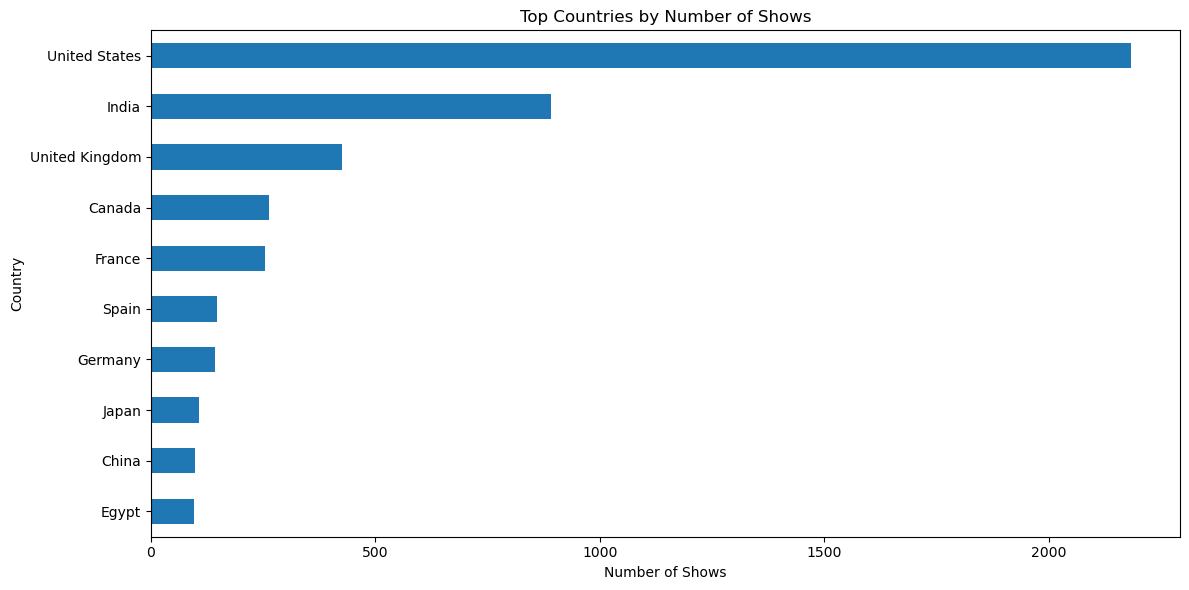

In [19]:

# Remove missing country values
country_df = df.dropna(subset=['Country'])

# Split multiple countries into separate rows
country_df = country_df.assign(
    Country=country_df['Country'].str.split(',')
).explode('Country')

# Remove extra spaces
country_df['Country'] = country_df['Country'].str.strip()

# Count number of shows by country
top_countries = country_df['Country'].value_counts().head(10)

# Create horizontal bar graph
plt.figure(figsize=(12,6))

top_countries.sort_values().plot(kind='barh')

plt.title('Top Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')

plt.tight_layout()

# Save the graph image
plt.savefig('top_countries_barh.png')

# Show the graph
plt.show()

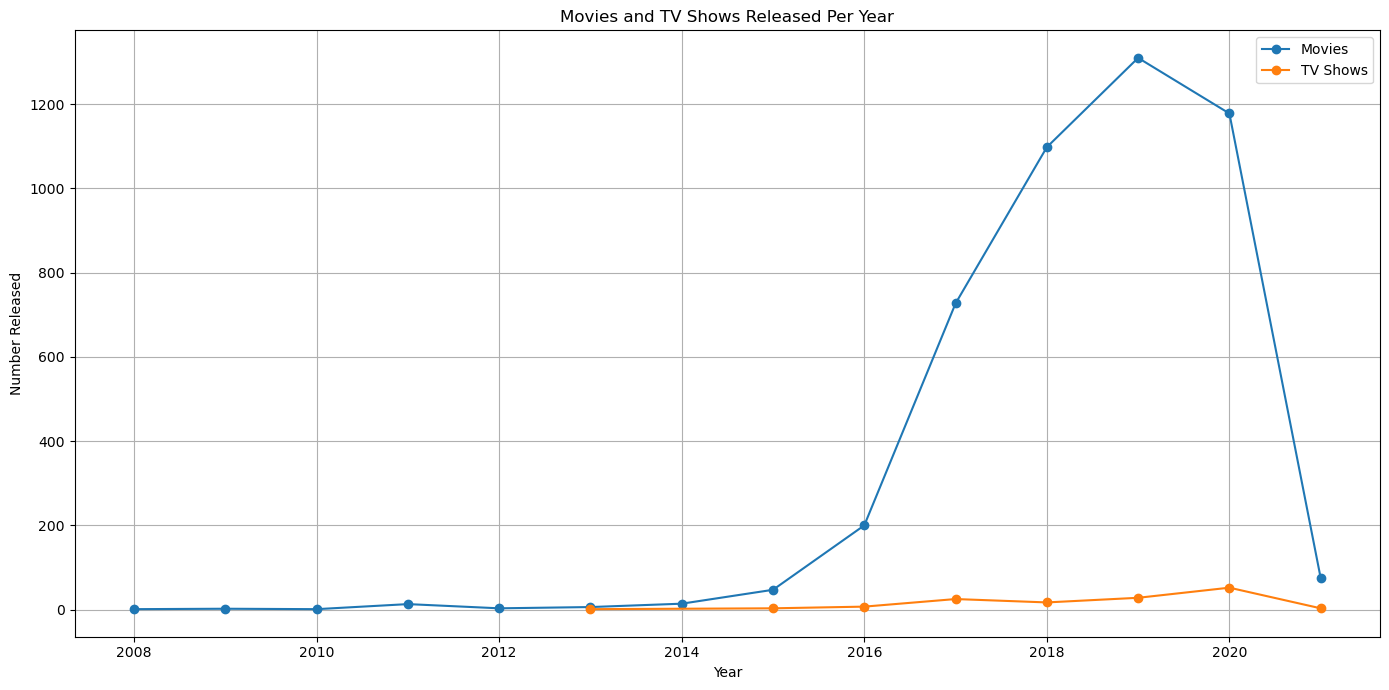

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove extra spaces and convert to datetime
df['Release_Date'] = pd.to_datetime(df['Release_Date'].str.strip())

# Extract year
df['Year'] = df['Release_Date'].dt.year

# Movies per year
movies_per_year = (
    df[df['Category'] == 'Movie']
    .groupby('Year')
    .size()
)

# TV Shows per year
tvshows_per_year = (
    df[df['Category'] == 'TV Show']
    .groupby('Year')
    .size()
)

# Plot graph
plt.figure(figsize=(14,7))

plt.plot(movies_per_year.index,
         movies_per_year.values,
         marker='o',
         label='Movies')

plt.plot(tvshows_per_year.index,
         tvshows_per_year.values,
         marker='o',
         label='TV Shows')

plt.title('Movies and TV Shows Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number Released')

plt.legend()
plt.grid(True)

plt.tight_layout()

# Save image
plt.savefig('movies_vs_tvshows.png')

plt.show()